In [8]:
import numpy as np
from numpy import random as rng
from matplotlib import pyplot as plt

(1024, 1)

(1024, 1)

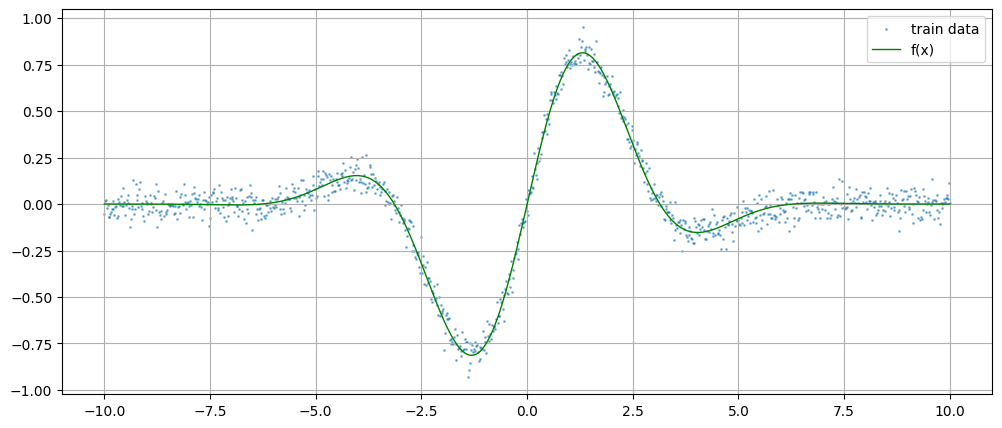

In [9]:
# Аппроксимация нелинейной функции f(x) = sin(x) · exp(-x²/10)

# f, xlim = lambda x: np.sin(x*2.9),(-1.,+2.)
# f, xlim = lambda x: np.sin(x*2.9)+np.cos(x*5.9),(-1., 1.)
# f, xlim = lambda x: np.exp( -np.square(x) ) + 1.5 * np.exp(-np.square(x-2) ), (-3,5)
f, xlim = lambda x: np.sin(x)*np.exp(-np.square(x)*0.1), ( -10., +10. )

x = np.linspace(xlim[0],xlim[1],1024).reshape(-1, 1)
y_true = f(x)
y = y_true + rng.normal(0.0, 0.05, x.shape)
display( x.shape, y.shape )

fig,ax = plt.subplots(1,figsize=(12,5))
ax.scatter( x, y, s=1, alpha=.5, label='train data')
ax.plot( x, y_true, 'g-', linewidth=1, label='f(x)')
ax.legend()
ax.grid()
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)
display( (x_train.shape, y_train.shape,), (x_test.shape,y_test.shape) )

((716, 1), (716, 1))

((308, 1), (308, 1))

In [11]:
from sklearn.mixture import GaussianMixture

class RBF:

    def __init__(self,n_components:int,size_out:int):
        self._gauss_mix = GaussianMixture(n_components)
        self._weight = np.zeros((n_components,size_out))

    def fit(self,x:np.ndarray,y:np.ndarray):    
        self._gauss_mix.fit(x)
        # Least Squares: W = (ΦᵀΦ)⁻¹Φᵀy
        self._weight = np.linalg.pinv( self._gauss_mix.predict_proba(x) ) @ y
        return self
    
    def score(self,x:np.ndarray)->np.ndarray :
        return self._gauss_mix.predict_proba(x) @ self._weight
    
    def predict(self,x:np.ndarray)->np.ndarray :
        return self.score(x)

In [12]:
i_test = np.argsort(x_test,axis=0).flatten()
x_test = x_test[i_test]
y_test = y_test[i_test]

In [13]:
model = RBF(n_components=25,size_out=y.shape[1]).fit(x_train,y_train)
o_test = model.predict( x_test )

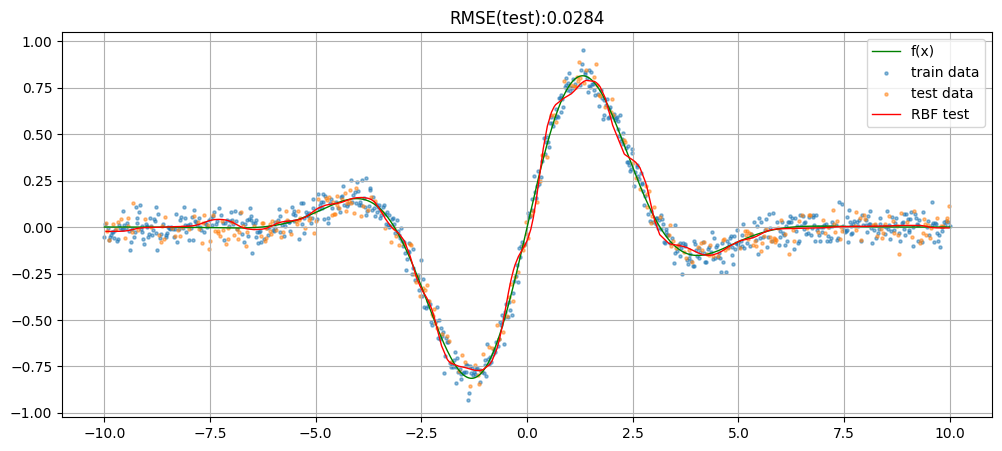

In [14]:
rmse = np.sqrt( np.square( o_test - f(x_test)).mean() )

fig,ax = plt.subplots(1,figsize=(12,5))
ax.plot( x, y_true, 'g-', linewidth=1, label='f(x)')
ax.scatter( x_train, y_train, s=5, alpha=.5, label='train data')
ax.scatter( x_test, y_test, s=5, alpha=.5, label='test data')
ax.plot( x_test, o_test, 'r-', linewidth=1, label='RBF test')
ax.set_title(f"RMSE(test):{rmse:.4f}" )
ax.grid()
ax.legend()
plt.show()
